In [5]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import Audio

In [8]:
# Project configuration
dataset_path = "../datasets/RAVDESS"

sample_file = os.path.join(
    dataset_path,
    "Actor_01",
    "03-01-01-01-01-01-01.wav"
)

print(sample_file)

../datasets/RAVDESS\Actor_01\03-01-01-01-01-01-01.wav


In [10]:
Audio(sample_file)

In [11]:
signal, sample_rate = librosa.load(
    sample_file,
    sr=None
)

print("Sample Rate :", sample_rate)
print("Total Samples :", len(signal))

Sample Rate : 48000
Total Samples : 158558


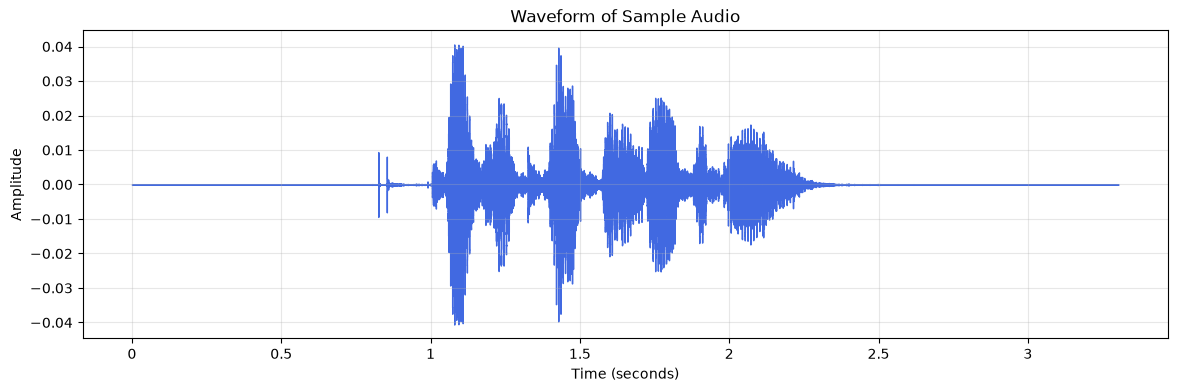

In [12]:
plt.figure(figsize=(14, 4))

librosa.display.waveshow(
    signal,
    sr=sample_rate,
    color="royalblue"
)

plt.title("Waveform of Sample Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.grid(alpha=0.3)

plt.show()

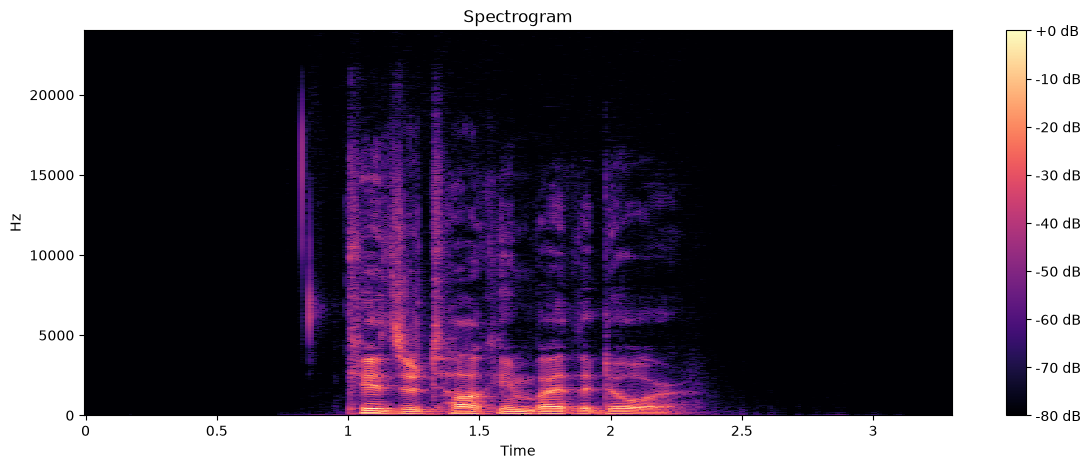

In [13]:
D = librosa.amplitude_to_db(
    np.abs(librosa.stft(signal)),
    ref=np.max
)

plt.figure(figsize=(14,5))

librosa.display.specshow(
    D,
    sr=sample_rate,
    x_axis="time",
    y_axis="hz",
    cmap="magma"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")

plt.show()

In [14]:
mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sample_rate,
    n_mfcc=13
)

print("MFCC Shape:", mfcc.shape)

MFCC Shape: (13, 310)


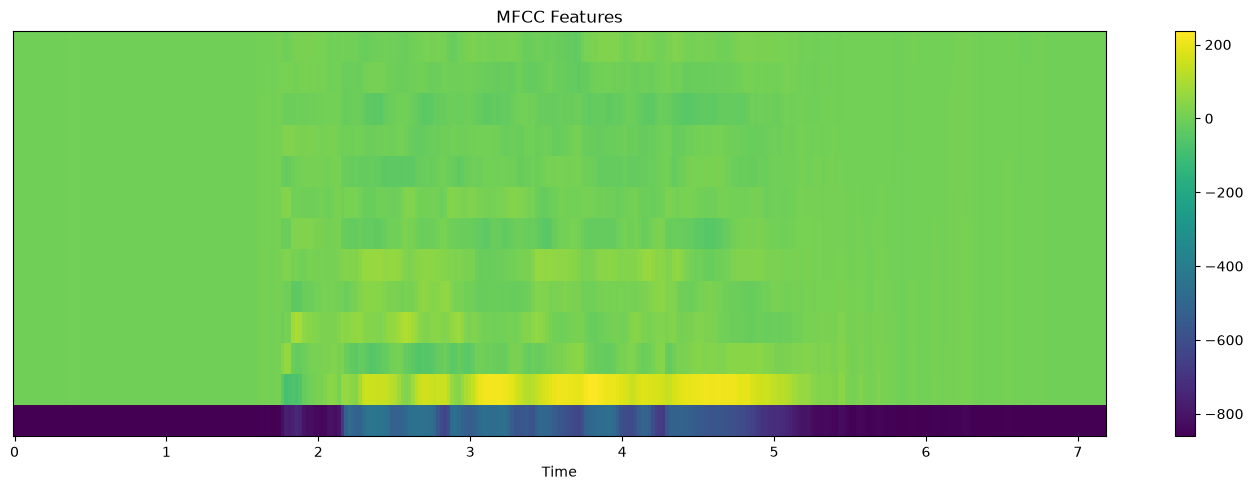

In [15]:
plt.figure(figsize=(14,5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    cmap="viridis"
)

plt.colorbar()
plt.title("MFCC Features")

plt.tight_layout()
plt.show()

In [16]:
chroma = librosa.feature.chroma_stft(
    y=signal,
    sr=sample_rate
)

print("Chroma Shape :", chroma.shape)

Chroma Shape : (12, 310)


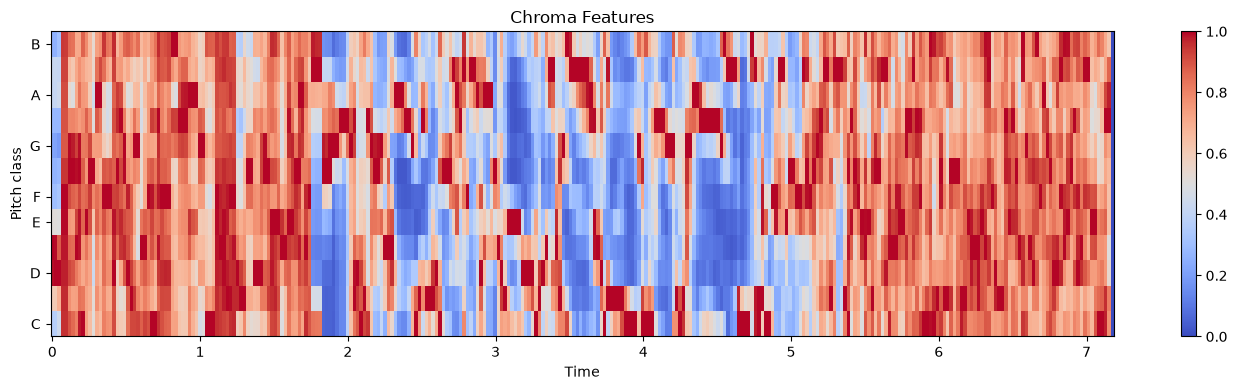

In [17]:
plt.figure(figsize=(14,4))

librosa.display.specshow(
    chroma,
    x_axis="time",
    y_axis="chroma",
    cmap="coolwarm"
)

plt.colorbar()

plt.title("Chroma Features")

plt.tight_layout()

plt.show()

In [18]:
mel = librosa.feature.melspectrogram(
    y=signal,
    sr=sample_rate
)

print(mel.shape)

(128, 310)


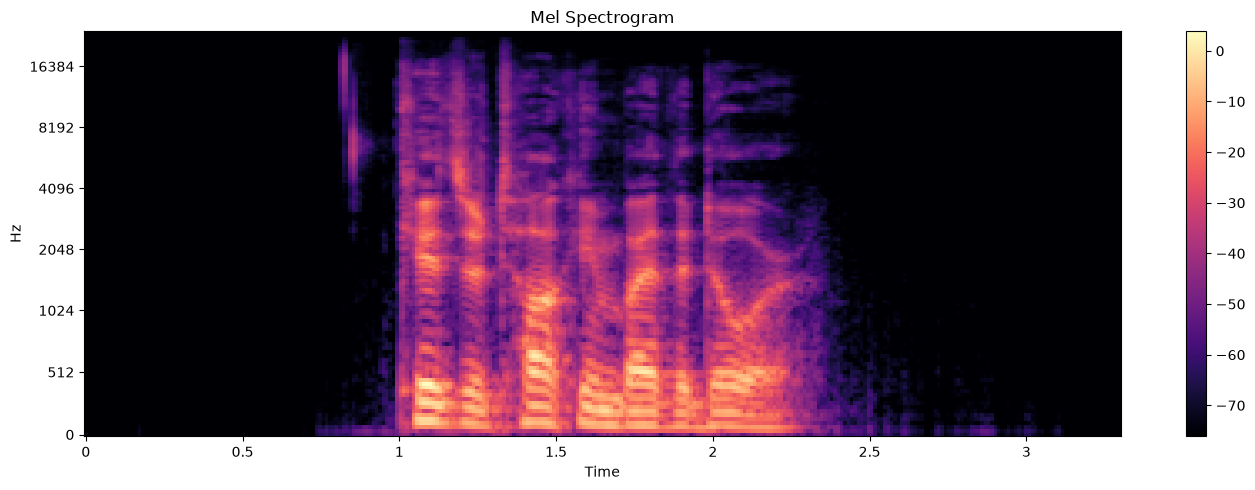

In [19]:
plt.figure(figsize=(14,5))

librosa.display.specshow(
    librosa.power_to_db(mel),
    sr=sample_rate,
    x_axis="time",
    y_axis="mel",
    cmap="magma"
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.tight_layout()

plt.show()

In [20]:
zcr = librosa.feature.zero_crossing_rate(signal)

print(zcr.shape)

(1, 310)


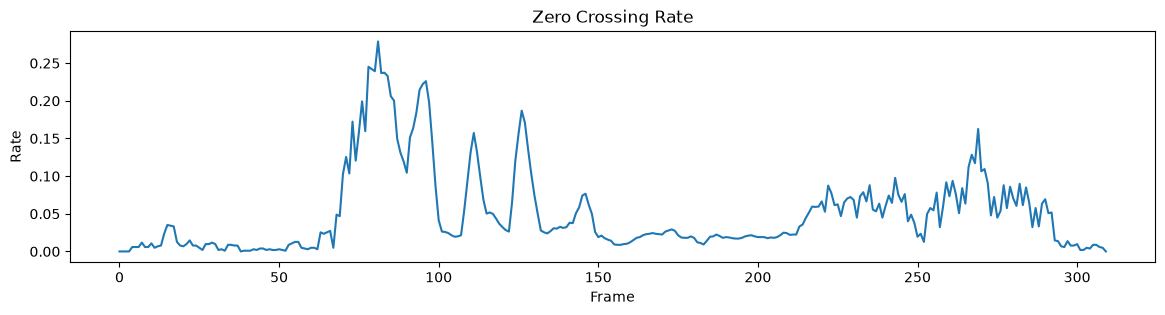

In [21]:
plt.figure(figsize=(14,3))

plt.plot(zcr[0])

plt.title("Zero Crossing Rate")

plt.xlabel("Frame")

plt.ylabel("Rate")

plt.show()

In [22]:
rms = librosa.feature.rms(y=signal)

print(rms.shape)

(1, 310)


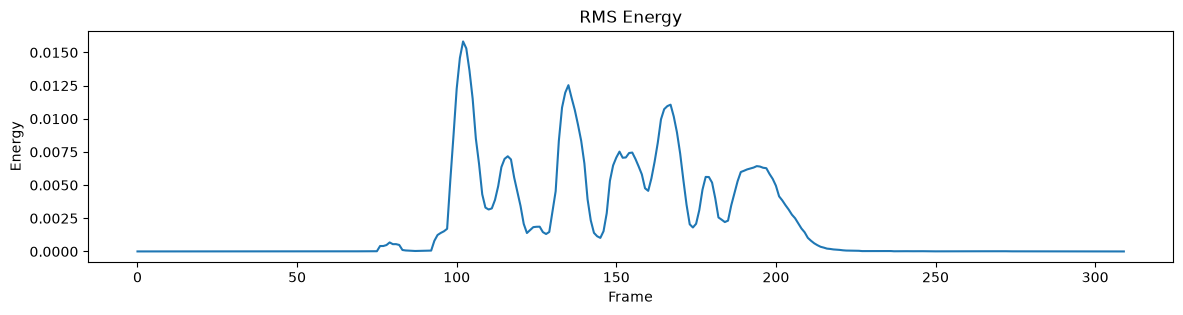

In [23]:
plt.figure(figsize=(14,3))

plt.plot(rms[0])

plt.title("RMS Energy")

plt.xlabel("Frame")

plt.ylabel("Energy")

plt.show()

In [24]:
centroid = librosa.feature.spectral_centroid(
    y=signal,
    sr=sample_rate
)

print(centroid.shape)

(1, 310)


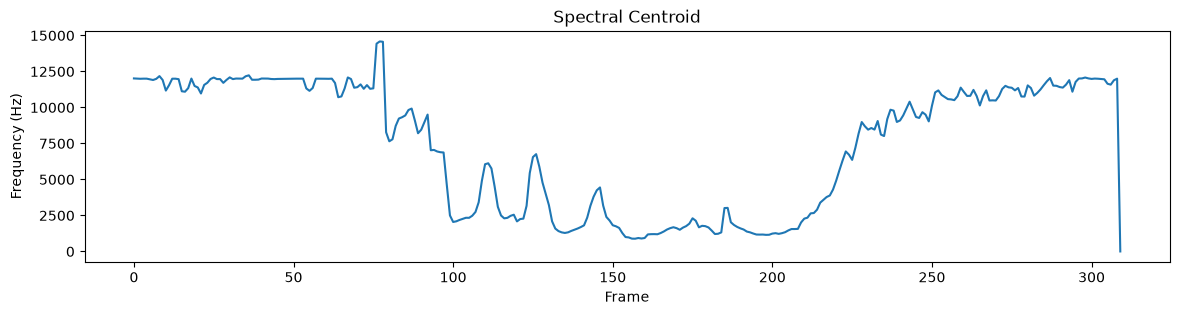

In [25]:
plt.figure(figsize=(14,3))

plt.plot(centroid[0])

plt.title("Spectral Centroid")

plt.xlabel("Frame")

plt.ylabel("Frequency (Hz)")

plt.show()